In [1]:
import os
import sys
import h5py
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from matplotlib import pyplot as plt
import colorsys
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties

labelfont = FontProperties()
labelfont.set_family('serif')
labelfont.set_name('Times New Roman')
labelfont.set_size(14)

axislabelfont = FontProperties()
axislabelfont.set_family('serif')
axislabelfont.set_name('Times New Roman')
axislabelfont.set_size(22)

tickfont = FontProperties()
tickfont.set_family('serif')
tickfont.set_name('Times New Roman')
tickfont.set_size(16)

axisfontsize = 16
labelfontsize = 16

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams['text.usetex'] = True

In [2]:
from snnae import SNNAE
from data_utils import get_cms_data, get_top_data
from dataset import cdataset

# CMS data

In [3]:
data = get_cms_data( num_events_per_class=20000, add_one_hot=False, drop_angles=True, pt_norm_method="max_per_category" )

sm data shape before any preprocessing: (20000, 19, 3)
sm data shape after dropping angles: (20000, 19, 1)
sm data shape after flattening: (20000, 19)


In [6]:
sm_dataset = cdataset( data["sm"], labels=np.zeros( data["sm"].shape[0] ) )
h0_dataset = cdataset( np.concatenate( [data["sm"],data["h0"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["h0"].shape[0])] ) )
hc_dataset = cdataset( np.concatenate( [data["sm"],data["hc"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["hc"].shape[0])] ) )
a4l_dataset = cdataset( np.concatenate( [data["sm"],data["a4l"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["a4l"].shape[0])] ) )
lq_dataset = cdataset( np.concatenate( [data["sm"],data["lq"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["lq"].shape[0])] ) )

batch_size = 1000

train_loader = DataLoader( sm_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_h0 = DataLoader( h0_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_hc = DataLoader( hc_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_a4l = DataLoader( a4l_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_lq = DataLoader( lq_dataset, batch_size=batch_size, shuffle=True, drop_last=True )

In [28]:
args_cms_data = {    "input_dim":data["sm"].shape[-1],
                "beta":0.5,
                "thresh":1.0,
                "num_steps":5,
                "latent_dim":5,
                "hidden_dim":64,
                "lr":0.001
           }

In [29]:
net = SNNAE( **args_cms_data )

In [30]:
net.train_model( train_loader, num_epochs=60 )

epoch 0 - loss: 0.019136013370007275
epoch 1 - loss: 0.012300607608631253
epoch 2 - loss: 0.007998422114178538
epoch 3 - loss: 0.00545658371411264
epoch 4 - loss: 0.004808337613940239
epoch 5 - loss: 0.0036178171867504716
epoch 6 - loss: 0.0028241948457434773
epoch 7 - loss: 0.0022477983846329154
epoch 8 - loss: 0.0018238553195260466
epoch 9 - loss: 0.001703172823181376
epoch 10 - loss: 0.0016470993170514703
epoch 11 - loss: 0.0016673659381922334
epoch 12 - loss: 0.001654132833937183
epoch 13 - loss: 0.0016267346451058983
epoch 14 - loss: 0.0016125943337101489
epoch 15 - loss: 0.0015545898233540357
epoch 16 - loss: 0.0014024158765096218
epoch 17 - loss: 0.0013246780377812683
epoch 18 - loss: 0.0012922682508360595
epoch 19 - loss: 0.0012522573641035705
epoch 20 - loss: 0.0011897372663952411
epoch 21 - loss: 0.001153385528596118
epoch 22 - loss: 0.0011811546806711703
epoch 23 - loss: 0.001112488645594567
epoch 24 - loss: 0.0010084968234878033
epoch 25 - loss: 0.0009530017880024389
epoch 

/home/b/Physics/snn-anomalies/snnae.py:172: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


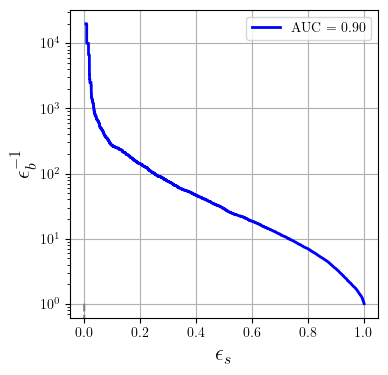

In [31]:
net.plot_roc_curve( test_loader_hc )

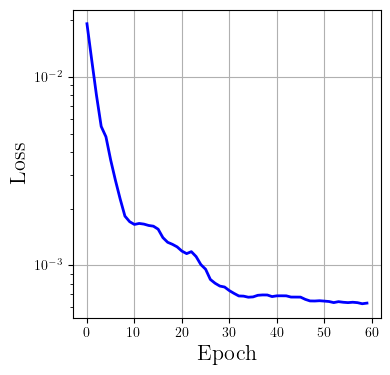

In [32]:
net.plot_loss_epochs( log_yscale=True )

# Top jet images

In [3]:
data = get_top_data( num_jets=200000, rescale=10)

In [29]:
data["qcd"].shape, data["top"].shape

((100078, 1600), (99922, 1600))

In [30]:
qcd_dataset = cdataset( data["qcd"], labels=np.zeros( data["qcd"].shape[0] ) )
qcd_top_dataset = cdataset( np.concatenate( [data["qcd"],data["top"]], axis=0 ), labels=np.concatenate( [np.zeros(data["qcd"].shape[0]),np.ones(data["top"].shape[0])] ) )

batch_size = 1000

train_loader = DataLoader( qcd_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader = DataLoader( qcd_top_dataset, batch_size=batch_size, shuffle=True, drop_last=True )

In [31]:
data["qcd"][0][ data["qcd"][0]!=0 ]

array([0.03956323, 5.81961084, 0.126448  , 0.31194094, 0.36243756,
       0.56754659, 0.62889321, 0.13381559, 0.14505823, 0.75459271,
       0.21274416, 0.15854829, 0.08876162, 0.09911513, 0.5263755 ,
       0.02454841])

Text(0, 0.5, '$\\phi$')

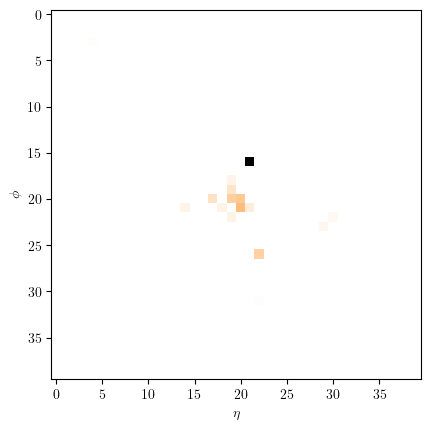

In [32]:
plt.imshow( data["qcd"][0].reshape(40,40), cmap='gist_heat_r'  )
plt.xlabel('$\eta$')
plt.ylabel('$\phi$')

In [47]:
args_top_data = {    "input_dim":data["qcd"].shape[-1],
                     "beta":0.5,
                     "thresh":1.0,
                     "num_steps":5,
                     "latent_dim":100,
                     "hidden_dim":256,
                     "lr":0.005
           }

In [48]:
net = SNNAE( **args_top_data )

In [52]:
net.train_model( train_loader, num_epochs=50 )

epoch 0 - loss: 0.0020710361003875733
epoch 1 - loss: 0.002062734819483012
epoch 2 - loss: 0.00205863134120591
epoch 3 - loss: 0.0020444560260511934
epoch 4 - loss: 0.002047621241072193
epoch 5 - loss: 0.0020416529150679708
epoch 6 - loss: 0.0020410259545315056
epoch 7 - loss: 0.0020349611504934728
epoch 8 - loss: 0.0020343801053240894
epoch 9 - loss: 0.0020314917247742413
epoch 10 - loss: 0.002027444497216493
epoch 11 - loss: 0.0020244380948133767
epoch 12 - loss: 0.0020251323899719864
epoch 13 - loss: 0.0020234591071493922
epoch 14 - loss: 0.0020274696638807655
epoch 15 - loss: 0.0020174002030398696
epoch 16 - loss: 0.002014416472520679
epoch 17 - loss: 0.0020177149865776302
epoch 18 - loss: 0.0020132393238600343
epoch 19 - loss: 0.0020149844151455907
epoch 20 - loss: 0.002013831794029102
epoch 21 - loss: 0.0020059876632876695
epoch 22 - loss: 0.0020046861842274665
epoch 23 - loss: 0.0020038759079761804
epoch 24 - loss: 0.0019967998610809445
epoch 25 - loss: 0.001998830100055784
epoc

/home/b/Physics/snn-anomalies/snnae.py:172: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


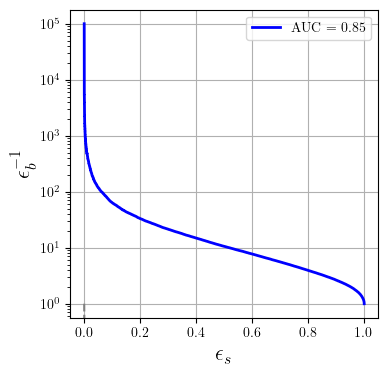

In [53]:
net.plot_roc_curve( test_loader )

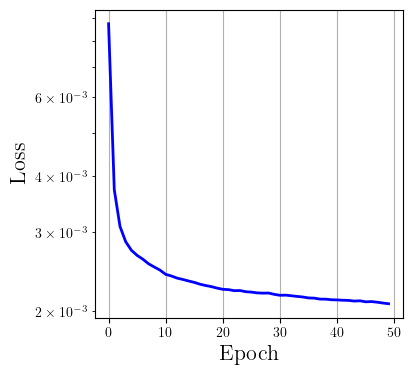

In [51]:
net.plot_loss_epochs( log_yscale=True )

# Top jet images - tagging QCD

In [3]:
data = get_top_data( num_jets=200000, rescale=10)

In [4]:
data["qcd"].shape, data["top"].shape

((100078, 1600), (99922, 1600))

In [5]:
top_dataset = cdataset( data["top"], labels=np.zeros( data["top"].shape[0] ) )
top_qcd_dataset = cdataset( np.concatenate( [data["top"],data["qcd"]], axis=0 ), labels=np.concatenate( [np.zeros(data["top"].shape[0]),np.ones(data["qcd"].shape[0])] ) )

batch_size = 1000

train_loader = DataLoader( top_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader = DataLoader( top_qcd_dataset, batch_size=batch_size, shuffle=True, drop_last=True )

In [6]:
args_top_data = {    "input_dim":data["qcd"].shape[-1],
                     "beta":0.5,
                     "thresh":1.0,
                     "num_steps":5,
                     "latent_dim":100,
                     "hidden_dim":256,
                     "lr":0.005
           }

In [7]:
net = SNNAE( **args_top_data )

In [8]:
net.train_model( train_loader, num_epochs=50 )

epoch 0 - loss: 0.006144060090071324
epoch 1 - loss: 0.004317544762872987
epoch 2 - loss: 0.004030885019650062
epoch 3 - loss: 0.003918843647239335
epoch 4 - loss: 0.0038566595917059617
epoch 5 - loss: 0.0038128167818855456
epoch 6 - loss: 0.0037816239337465076
epoch 7 - loss: 0.003753797452181879
epoch 8 - loss: 0.003735014209241578
epoch 9 - loss: 0.0037116323823504376
epoch 10 - loss: 0.003695644200732461
epoch 11 - loss: 0.003672111379641174
epoch 12 - loss: 0.0036625129340047188
epoch 13 - loss: 0.0036499762902920596
epoch 14 - loss: 0.003645863433396726
epoch 15 - loss: 0.0036330290910119964
epoch 16 - loss: 0.0036313369037639914
epoch 17 - loss: 0.0036174590755818467
epoch 18 - loss: 0.003612261281979054
epoch 19 - loss: 0.0036056967513315905
epoch 20 - loss: 0.003597293020875165
epoch 21 - loss: 0.003593255648144869
epoch 22 - loss: 0.003584475491685097
epoch 23 - loss: 0.003580344577479844
epoch 24 - loss: 0.003577191187445112
epoch 25 - loss: 0.003571782207041226
epoch 26 - l

/home/b/Physics/snn-anomalies/snnae.py:172: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr


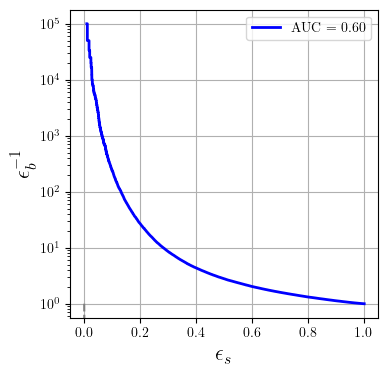

In [9]:
net.plot_roc_curve( test_loader )

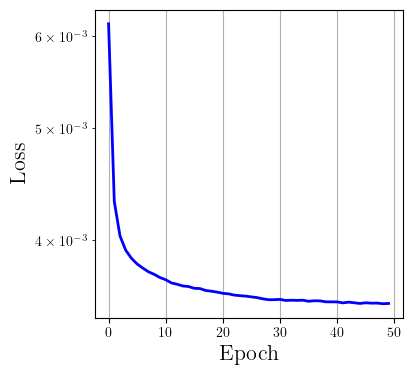

In [10]:
net.plot_loss_epochs( log_yscale=True )